### **4.3 ARMA and ARIMA Process**

**Overview**

In this activity, you will explore **ARMA** and **ARIMA** models for time series forecasting using a fictional industrial dataset. You will be asked to complete key parts of the code, with a particular focus on:

- Model selection and evaluation

- Interpretation of time series patterns

- Communicating results effectively through visualisations

Analysts should view these skills as a competitive advantage, especially in situations where machine learning alone cannot explain why a pattern is important or what action should follow from a forecast.

**ARMA process**

The ARMA (AutoRegressive Moving Average) model is a time series model frequently used when data are **stationary** - meaning the statistical properties of the series do not change over time.

In this section, you will explore how to:

- Identify whether an ARMA model is appropriate for the data

- Interpret autocorrelation and partial autocorrelation plots (ACF & PACF)

- Fit and evaluate an ARMA model using the `statsmodels` library

---

**Dataset: `ElectricalSignaldata.csv`**

This dataset simulates data from an industrial system monitoring electrical signals emitted per minute.

- Variable: `ElectricalSignals` - *float*, representing the number of electrical signals sent each minute.
- Number of records: 1,000
- Use Case: Think of a predictive maintenance scenario where signal patterns may help detect anomalies or forecast potential failures in an electrical system.

**Note**: These are fictional data. Focus on technique, critical interpretation, and communication - not on real-world validity.

<img src="Id_MAq_process.png" alt="Autoregression Model Identification" width="700">

**Library Imports and Setup**

Before we begin modelling, we need to import the relevant libvraries. These cover a range of tasks including:

- **Data manipulation and plotting**: Using `pandas`, `numpy`, and `matplotlib`

- **Time series modelling**: Tools from `statsmodels` for building and diagnosing ARMA/ARIMA models

- **Model evaluation**: Metrics like MAE and RMSE from `sklearn` to assess prediction accuracy

- **Hyperparameter tuning**: Using `itertools.product` and `tqdm` for simple grid search and progress feedback

- **Plotting configuration**: `%matplotlib inline` to show plots in the notebook, and warnings are suppressed for cleaner output

In [14]:
# Needed to install required packages first
# python -m pip install ipywidgets

# Time series tools from the statsmodels library
from statsmodels.tsa.stattools import adfuller          # for stationarity testing
from statsmodels.tsa.statespace.sarimax import SARIMAX  # for advanced modelling
from statsmodels.graphics.tsaplots import plot_acf      # for autocorrelation plots
from statsmodels.graphics.tsaplots import plot_pacf     # for partial autocorrelation plots
from statsmodels.tsa.arima_process import ArmaProcess   # for simulating ARMA processes
from statsmodels.graphics.gofplots import qqplot        # for Q-Q plots
from statsmodels.stats.diagnostic import acorr_ljungbox # for the Ljung-Box test

# Data manipulation
import pandas as pd
import numpy as np
from typing import Union

# Machine learning tools from the scikit-learn library
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

# Plotting library
%matplotlib inline
import matplotlib.pyplot as plt

# Model tuning and visual feedback
from tqdm.notebook import tqdm
from itertools import product

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Remember to run this in the terminal to save the current environment's packages to a requirements file:
# python -m pip freeze > requirements.txt

In [2]:
# Read the dataset
df = pd.read_csv("./data/ElectricalSignaldata.csv")

In [3]:
df.head()

,ElectricalSignals
0,0.496714
1,0.472694
2,0.679240
3,2.330099
4,1.905506


**Plotting the Raw Time Series**

Before applying any models, it is useful to visualise the data. As before, this initial plot helps identify patterns, trends, seasonality, or potential anomalies in the signal. We will use a simple line plot to get a sense of the overall behaviour of the time series.

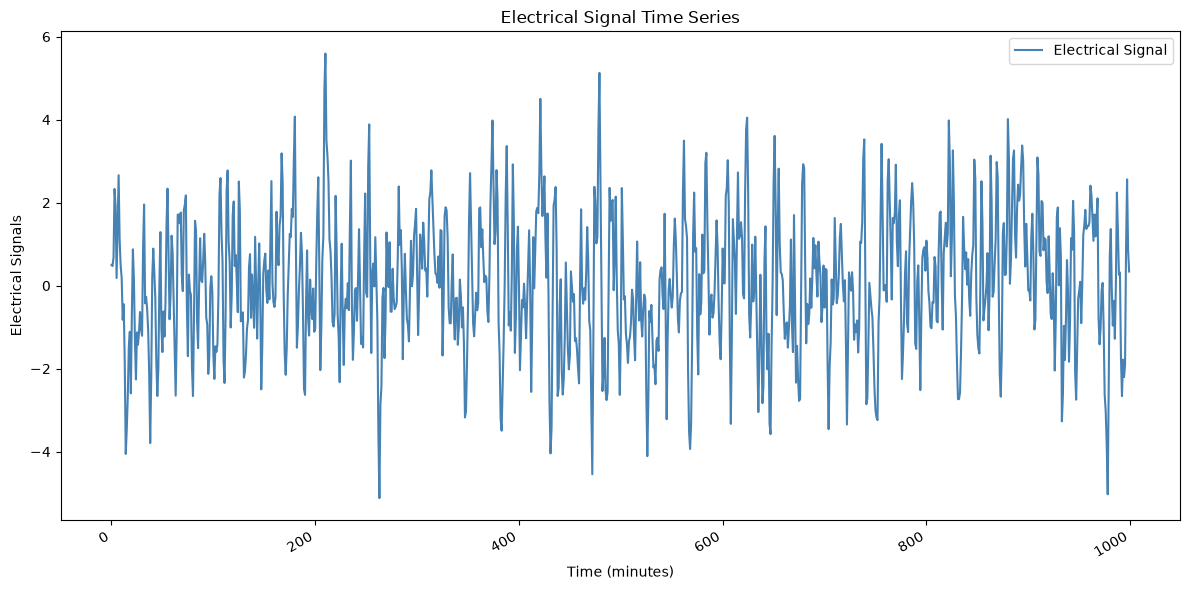

In [4]:
# Plot the electrical signal time series
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the signal
ax.plot(df["ElectricalSignals"], color='steelblue', label='Electrical Signal')
ax.set_title("Electrical Signal Time Series")
ax.set_xlabel("Time (minutes)")
ax.set_ylabel("Electrical Signals")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Testing for Stationarity**

To apply an ARMA model, the time series should be stationary. We will use the Aumented Dickey-Fuller (ADF) test to check this. The test evaluates the null hypothesis that a unit root is present (i.e. the series is non-stationary). A low p-value (typically below 0.05) suggests the data is stationary.

In [5]:
# Check for stationarity using the Augmented Dickey-Fuller test
ADF_result = adfuller(df["ElectricalSignals"])

print("ADF Statistic: %f" % ADF_result[0])
print("p-value: %f" % ADF_result[1])
for key, value in ADF_result[4].items():
    print(f"Critical Value ({key}): {value:.3f}")

ADF Statistic: -6.429879
p-value: 0.000000
Critical Value (1%): -3.437
Critical Value (5%): -2.864
Critical Value (10%): -2.568


The ADF test statistic is **-6.43** which is significantly lower (more negative) than all the critical values at the 1%, 5%, and 10% significance levels. Additionally, the **p-value** is extremely small (**1.71e-08**), well below the standard 0.05 threshold.

We can conclude that the time series is **stationary**, and we can proceed with ARMA modelling without applying differencing.

<div style="border:2px solid #00ffff; padding: 10px; border-radius: 5px; width: 1200px;">

**Note**:

The critical values in the ADF test represent thresholds for rejecting the null hypothesis at different confidence levels (1%, 5%, and 10%).

If the **ADF Statistic** is more negative than the critical value (e.g. -6.430 < -3.437 at 1%), we reject the null hypothesis and conclude that the series is likely stationary.

While the **p-value** is a quick indicator, comparing the test statistic to critical values gives a more transparent understanding of the result - and is often preferred in formal setting.
</div>

**Autocorrelation Function (ACF) Plot**

The ACF plot shows how correlated the time series is with its own past values. This helps in identifying the **MA (Moving Average)** component of an ARMA model.

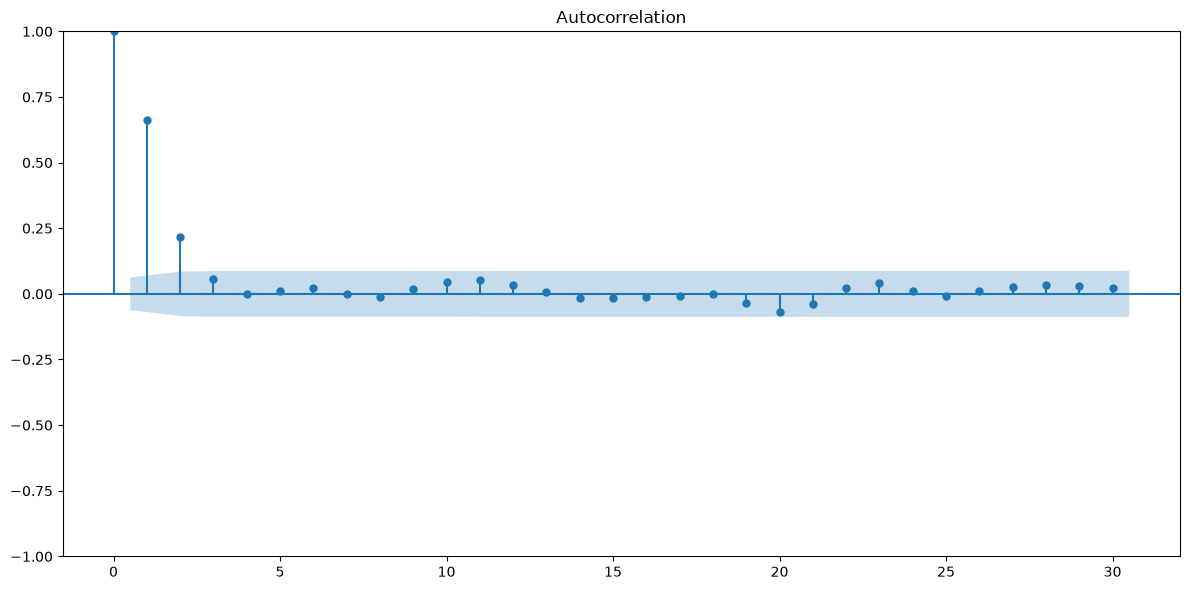

In [6]:
# Plot the Autocorrelation Function (ACF)
fig = plot_acf(df["ElectricalSignals"])

# Adjust plot size
fig.set_size_inches(12, 6)

# Improve layout
plt.tight_layout()

plt.show()

**Interpreting the ACF Plot**

The autocorrelation plot shows:

- A strong spike at **lag 1**, followed by a smaller spike at **lag 2**.

- After lag 2, the autocorrelation values show a mild **oscillating pattern**, but all remain **within the confidence bounds**, indicating they are **not statistically significant**.

**Preliminary Conclusion**

The ACF plot is consistent with a **Moving Average (MA)** process, likely **MA(1)** or **MA(2)**. There is no strong evidence of autocorrelation at higher lags, and no significant seasonal pattern.

We will confirm this by examining the **PACF plot** next, which can help identify whether an autoregressive (AR) component is present.

**Partial Autocorrelation (PACF) Plot**

The PACF plot helps identify the presence of autoregressive (AR) components in a time series. Each bar shows the strength of the relationship between the series and its lagged values, **after removing the effects of earlier lags**. If there is a significant spike at lag *p* and the rest fall within the confidence bounds, this suggests an **AR(p)** process. We will use this to check if our series has an AR component, or if a pure MA model is more appropriate.

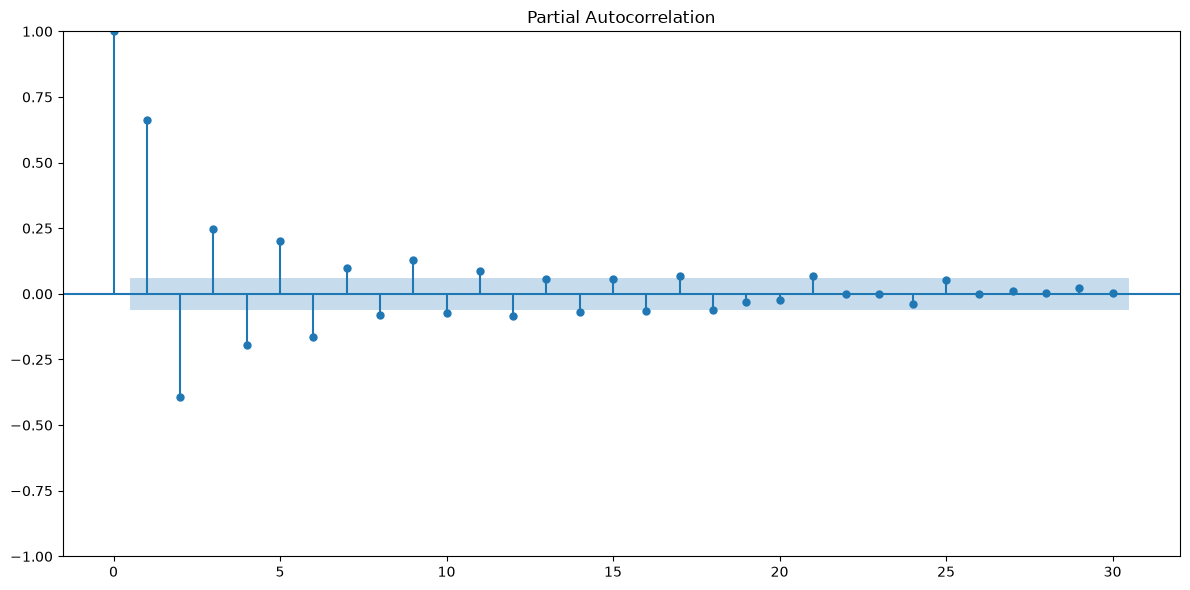

In [7]:
# Plot the Partial Autocorrelation Function (PACF)
fig = plot_pacf(df["ElectricalSignals"])

# Adjust plot size
fig.set_size_inches(12, 6)

# Improve layout
plt.tight_layout()
plt.show()

**PACF Interpretation**

The PACF plot shows a sinusoidal pattern with several significant spikes, but no clear point where the values cut off. This is common in ARMA processes, where both AR and MA terms influence the series.

<span style="color:red;font-weight:bold">Warning</span>: This pattern makes it difficult to determine the exact AR order (`p`) just by looking at the PACF.

**Conclusion**: We cannot reliably identify the order of an ARMA(p, q) model using the PACF plot alone, especially when both the ACF and PACF plots show **gradual decay** or **sinusoidal patterns**. We need to try different models and use a metric like **AIC** (Akaike Information Criterion) to find the best-fitting one.

<span style="color:orange;font-weight:bold">Remember</span>: If your time series is **stationary** and both the ACF and PACF plots show **gradual decay** or **wave-like (sinusoidal) patterns** - rather than a sharp drop-off - this usually indicates an **ARMA(p, q)** process.

**General Procedure for ARMA(p, q) Modelling**

Since the ACF and PACF plots suggest an ARMA process but don't clearly point to specific values of **p** and **q**, we now move to model fitting.

The image below shows the process we will follow: trying combinations of ARMA(p, q) models, checking how well they fit using AIC, and validating them by looking at the residuals.

This helps us move from "something looks ARMA-like" to a model we can actually use.

**Step 1: Define model combinations**

We will test a range of values for `p` and `q` - the AR and MA orders - by generating all combinations from 0 to 3. These will be used to fit ARMA(p, q) models and compare their performance.

In [8]:
# Try values from 0 to 3 (inclusive) for both p and q
ps = range(0, 4)
qs = range(0, 4)

# Create a list of all (p, q) combinations
order_list = list(product(ps, qs))

# Display the combinations
print("ARIMA (p, q) combinations:")
print(order_list)

ARIMA (p, q) combinations:
[(0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2), (2, 3), (3, 0), (3, 1), (3, 2), (3, 3)]


**Step 2: Fit ARMA Models and Compare AIC**

Now that we have defined a list of ARMA(p, q) combinations, we will fit each one and compute its **AIC (Akaike Information Criterion)**.

Lower AIC means a better trade-off between model fit and complexity. The function below returns a sorted table so we can easily find the best candidate.

In [9]:
def optimise_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    """
    Function to find the best ARMA model based on AIC and BIC values.

    Parameters:
    endog (Union[pd.Series, list]): The time series data.
    order_list (list): List of (p, q) combinations to evaluate.

    Returns:
    pd.DataFrame: DataFrame containing the order, AIC, and BIC for each model.
    """
    results = []
    
    for order in tqdm(order_list, desc="Fitting models"):
        try:
            # Fit the ARMA model
            model = SARIMAX(endog, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False)
            
            # Append the results
            results.append([order, model.aic])
        except:
            continue

    # Convert results to DataFrame
    results_df = pd.DataFrame(results, columns=['Order(p,q)', 'AIC'])

    # Sort the DataFrame by AIC
    return results_df.sort_values(by='AIC').reset_index(drop=True)

**Step 3: Run Model Comparison**

We now run the model selection function on our data. This fits each ARMA(p, q) combination and ranks them by **AIC**, so we can identify the best model. The top row in the results is the model with the lowest AIC - this is our best candidate so far.

In [10]:
# Step 3: Use the function to find the best ARMA(p, q) model based on AIC
result_df = optimise_ARMA(df["ElectricalSignals"], order_list)

# Display the results
print(result_df)

Fitting models:   0%|          | 0/16 [00:00<?, ?it/s]

   Order(p,q)          AIC
0      (1, 1)  2801.407785
1      (2, 1)  2802.906070
2      (1, 2)  2802.967762
3      (0, 3)  2803.666793
4      (1, 3)  2804.524027
5      (3, 1)  2804.588567
6      (2, 2)  2804.822282
7      (2, 3)  2806.175380
8      (3, 3)  2806.418047
9      (3, 2)  2806.894930
10     (0, 2)  2812.840730
11     (0, 1)  2891.869245
12     (3, 0)  2981.643911
13     (2, 0)  3042.627787
14     (1, 0)  3207.291261
15     (0, 0)  3780.418416


**Step 4: Residual Analysis**

Once we have selected a candidate ARMA(p, q) model (e.g. ARMA(1, 1)) we need to check whether it fits well. We do this by analysing the **residuals** - the difference between the model's predictions and the actual data. Ideally, the residuals should behave like **white noise** (no structure, no correlation).

The summary output below gives parameter estimates and overall model fit statistics. In the next step, we will visualise the residuals to confirm that the model is appropriate.

In [11]:
# Step 4: Fit the best ARMA model based on AIC
model = SARIMAX(df["ElectricalSignals"], order=(result_df.iloc[0]['Order(p,q)'][0], 0, result_df.iloc[0]['Order(p,q)'][1]), simple_differencing=False)
model_fit = model.fit(disp=False)

# Extract residuals
residuals = model_fit.resid

# Show the summary of the fitted model
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:      ElectricalSignals   No. Observations:                 1000
Model:               SARIMAX(1, 0, 1)   Log Likelihood               -1397.704
Date:                Wed, 22 Jul 2026   AIC                           2801.408
Time:                        12:54:13   BIC                           2816.131
Sample:                             0   HQIC                          2807.004
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3103      0.032      9.572      0.000       0.247       0.374
ma.L1          0.9203      0.014     66.415      0.000       0.893       0.948
sigma2         0.9560      0.042     22.825      0.0

The Q-Q (quantile-quantile) plot helps us check whether the residuals are **normally distributed**, which in one assumption of a well-behaved ARMA model.

If the residuals fall roughly along the 45-degree line, that is a good sign. If they deviate heavily -  especially at the ends - the model may not be a good fit.

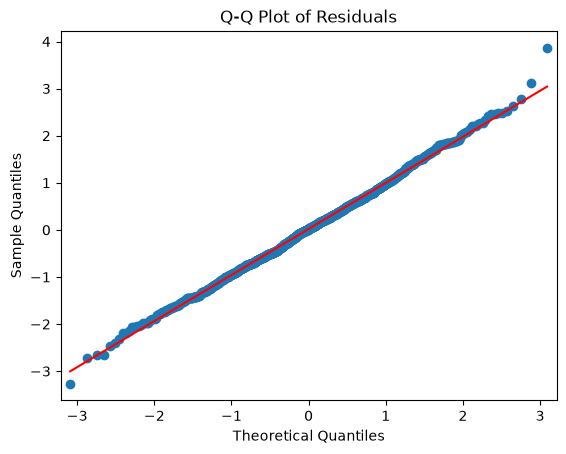

In [13]:
# Generate the Q-Q plot for the residuals
qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()

Test if they are uncorrelated using ljung-box test. The Ljung-Box test checks if the residuals are **uncorrelated**, which is what we want. If the **p-values are above 0.05**, we **don't have evidence of autocorrelation**, so we treat the residuals as white noise. This means our model has likely done a good job capturing the structure in the data. The test complements the Q-Q plot and helps confirm whether our model has adequately captured the structure in the data.

In [15]:
# Step 4 (continued): Use Ljung-Box test to check for autocorrelation in the residuals
ljungbox_result = acorr_ljungbox(residuals, lags=np.arange(1, 11), return_df=True)

# Display the Ljung-Box test results
print(ljungbox_result)

     lb_stat  lb_pvalue
1   0.030706   0.860897
2   0.528021   0.767966
3   0.540904   0.909817
4   2.079774   0.721089
5   2.271897   0.810385
6   2.896262   0.821750
7   2.900378   0.894063
8   4.418799   0.817501
9   4.787567   0.852419
10  5.246805   0.874093


All p-values from the Ljung-Box test are well above 0.05 for lags 1 to 10. This means we **fail to reject** the null hypothesis of no autocorrelation at all tested lags.

**Conclusion**: We can treat the residuals as **white noise**, suggesting that the model has successfully captured the structure in the data and is likely a good fit.

**Forecasting with the Final Model**

Now that our model has passed residual checks, we can move on to forecasting.

We will split the data to simulate a real scenario: fit the model on the earlier data, and forecast the last 30 minutes to see hope well it performs out-of-sample.

In [16]:
# Create Training and Testing Sets for forecasting 30 minutes ahead
train = df[:-30]
test = df[-30:]

# Print the sizes of the training and testing sets
print(f"Training set size: {len(train)}")
print(f"Testing set size: {len(test)}")

Training set size: 970
Testing set size: 30


In [17]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    """
    Function to perform rolling forecast using ARMA model.

    Parameters:
    df (pd.DataFrame): The time series data.
    train_len (int): Length of the training set.
    horizon (int): Forecast horizon.
    window (int): Rolling window size.
    method (str): Forecasting method ('ARMA').

    Returns:
    list: List of forecasted values.
    """

    total_len = train_len + horizon

    if method == "mean":
        pred_mean = []
        for i in range(train_len, total_len, window):
            mean_val = np.mean(df[:i].values)
            pred_mean.extend([mean_val] * window)
        return pred_mean

    elif method == "last":
        pred_last = []
        for i in range(train_len, total_len, window):
            last_val = df[:i].values[-1]
            pred_last.extend([last_val] * window)
        return pred_last

    elif method == "ARMA":
        pred_arma = []
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(result_df.iloc[0]['Order(p,q)'][0], 0, result_df.iloc[0]['Order(p,q)'][1]), simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(start=i, end=i + window - 1)
            forecast = predictions.predicted_mean.iloc[-window:]
            pred_arma.extend(forecast)
        return pred_arma

    else:
        raise ValueError("Invalid method. Choose from 'mean', 'last', or 'ARMA'.")

In [18]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

pred_mean = rolling_forecast(df["ElectricalSignals"], TRAIN_LEN, HORIZON, WINDOW, method="mean")
pred_last = rolling_forecast(df["ElectricalSignals"], TRAIN_LEN, HORIZON, WINDOW, method="last")
pred_arma = rolling_forecast(df["ElectricalSignals"], TRAIN_LEN, HORIZON, WINDOW, method="ARMA")

test.loc[:, 'Pred_Mean'] = pred_mean
test.loc[:, 'Pred_Last'] = pred_last
test.loc[:, 'Pred_ARMA'] = pred_arma

test.head()

,ElectricalSignals,Pred_Mean,Pred_Last,Pred_ARMA
970,-1.414633,0.078726,-0.772847,-1.448117
971,-1.032586,0.078726,-0.772847,-0.441395
972,-0.113056,0.076046,-1.032586,-0.894347
973,0.066647,0.076046,-1.032586,-0.272503
974,-1.011552,0.075842,0.066647,-0.545498


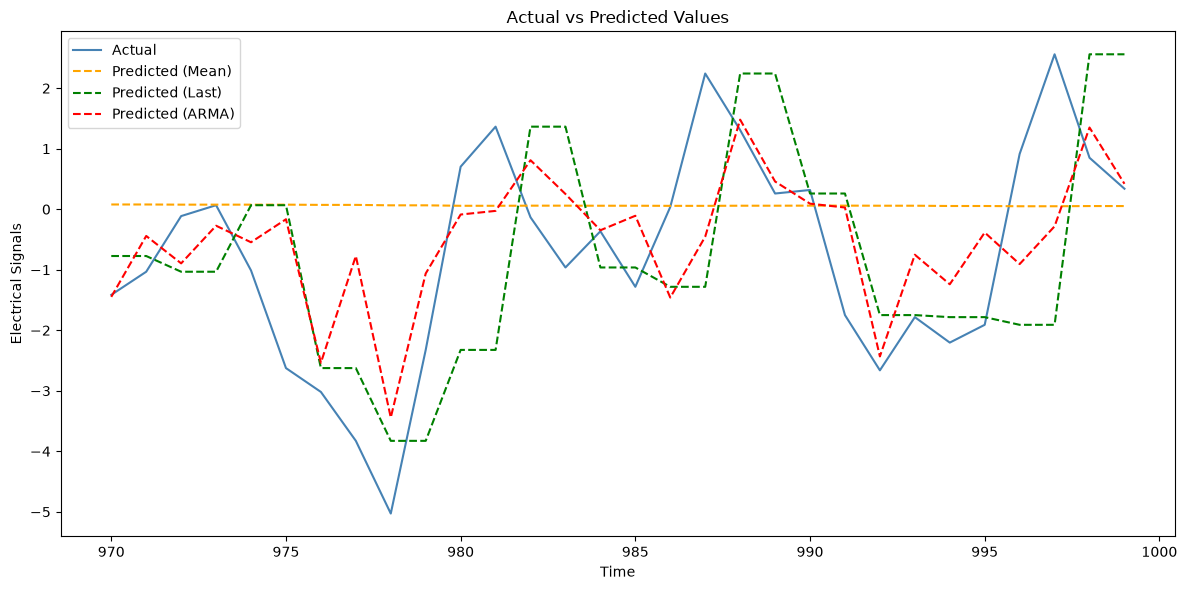

In [20]:
# Plot the actual vs predicted values for the test set
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(test["ElectricalSignals"], label='Actual', color='steelblue')
ax.plot(test["Pred_Mean"], label='Predicted (Mean)', color='orange', linestyle='--')
ax.plot(test["Pred_Last"], label='Predicted (Last)', color='green', linestyle='--')
ax.plot(test["Pred_ARMA"], label='Predicted (ARMA)', color='red', linestyle='--')

ax.set_title('Actual vs Predicted Values')
ax.set_xlabel('Time')
ax.set_ylabel('Electrical Signals')
ax.legend(loc=2)

plt.tight_layout()
plt.show()

In [21]:
# Calculate error
mse_mean = mean_squared_error(test["ElectricalSignals"], test["Pred_Mean"])
mse_last = mean_squared_error(test["ElectricalSignals"], test["Pred_Last"])
mse_arma = mean_squared_error(test["ElectricalSignals"], test["Pred_ARMA"])

# Display the Mean Squared Errors
print(f"Mean Squared Error (Mean): {mse_mean:.4f}")
print(f"Mean Squared Error (Last): {mse_last:.4f}")
print(f"Mean Squared Error (ARMA): {mse_arma:.4f}")

Mean Squared Error (Mean): 3.6935
Mean Squared Error (Last): 3.5664
Mean Squared Error (ARMA): 1.8712


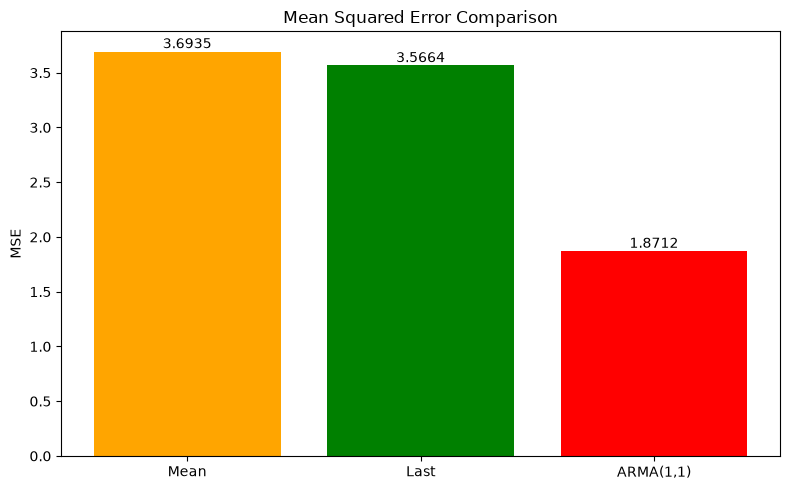

In [23]:
# Plot the mse values for comparison
fig, ax = plt.subplots(figsize=(8, 5))
mse_values = [mse_mean, mse_last, mse_arma]
labels = ['Mean', 'Last', 'ARMA(1,1)']
ax.bar(labels, mse_values, color=['orange', 'green', 'red'])
ax.set_title('Mean Squared Error Comparison')
ax.set_ylabel('MSE')

for index, value in enumerate(mse_values):
    ax.text(index, value, f"{value:.4f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

**ARIMA Process**

In the previous section, we worked with an **ARMA model**, which assumes the data is already **stationary**. Now we will look at **ARIMA** - AutoRegressive Integrated Moving Average - which is useful when the data shows **trending behaviour**.

Each part of ARIMA(p, d, q) has a job:

- **AR (p)** - uses past values to predict the future
- **I (d)** - removes trends by differencing the data
- **MA (q)** - smooths noise using past forecast errors

ARIMA does **not** handle seasonality.

If your data shows clear seasonal cycles (like yearly or quarterly patterns), you can:

- Use **SARIMA**, which includes seasonal components, or

- Remove seasonality during preprocessing (e.g. seasonal differencing), then apply ARIMA.

In practice, **SARIMA is the simpler and more robust option** for seasonal data.

Load the Johnson & Johnson earnings data, which we will use to explore the ARIMA process.

In [26]:
df2 = pd.read_csv("./data/JohnsonAndJohnson_4.csv", parse_dates=['time'], index_col='time')
df2.head()

,JohnsonJohnson
time,
1960-01-01,0.71
1960-01-04,0.63
1960-02-07,0.85
1960-01-10,0.44
1961-01-01,0.61


In [27]:
# Check for stationarity using the Augmented Dickey-Fuller test on the new dataset
ADF_result_df2 = adfuller(df2["JohnsonJohnson"])

print("ADF Statistic: %f" % ADF_result_df2[0])
print("p-value: %f" % ADF_result_df2[1])

ADF Statistic: 2.742017
p-value: 1.000000


The p-value is greater than 0.05. We failt to reject the null hypothesis of a unit root. The original Johnson & Johnson data is **not stationary**.

Since the original Johnson & Johnson data is not stationary, we:

- apply **first-order differencing** to remove the trend.
- then use the **ADF test** again to check if the differenced series is now stationary.

In [28]:
# Apply first-order differencing to remove trend and achieve stationarity
fdiff = np.diff(df2["JohnsonJohnson"], n=1)

# Run ADF test on the differenced data
ADF_result = adfuller(fdiff)

# Print the results of the ADF test on the differenced data
print("ADF Statistic (Differenced): %f" % ADF_result[0])
print("p-value (Differenced): %f" % ADF_result[1])

ADF Statistic (Differenced): -0.407410
p-value (Differenced): 0.908854


Even after first-order differencing, the series is **still not stationary**. We may need to apply **second-order differencing** to remove remaining trends or long-term structure.

In [29]:
# Apply second-order differencing to remove trend and achieve stationarity
fdiff2 = np.diff(df2["JohnsonJohnson"], n=2)

# Run ADF test on the differenced data
ADF_result2 = adfuller(fdiff2)

# Print the results of the ADF test on the differenced data
print("Second-order ADF Statistic (Differenced): %f" % ADF_result2[0])
print("Second-order p-value (Differenced): %f" % ADF_result2[1])

Second-order ADF Statistic (Differenced): -3.585163
Second-order p-value (Differenced): 0.006051


The p-value is well below 0.05, so we **reject the null hypothesis**. The second-order differenced series is now **stationary**, which means we have removed the trend.

Since we applied differencing **twice**, we set **d = 2** in our ARIMA(p,d,q) model. We can now proceed with an ARIMA(p,2,q) model.

**Optimising ARIMA(p,d,q) using AIC**

We define a function to try different combinations of AR(p) and MA(q) values, keeping d=2 (based on our differencing step).

For each (p,q) pair, the function fits an ARIMA(p,2,q) model and records the AIC value. We then select the model with the **lowest AIC**, which balances goodness of fit and model complexity.